# Stadium Extraction from LiDAR Elevation Data
ERSIP final assignment, activity 3

**Author: Joshua Mangotang**

In this notebook, my aim is to extract stadium structures from high-resolution Digital Surface Model (DSM) imagery over Liverpool, United Kingdom, obtained from the UK Environment Agency (https://environment.data.gov.uk/survey). The approach is based on morphological tree representations and attribute profiles to filter connected components according to their geometric properties. In addition to standard attributes such as `area`, `height`, `compactness`, `contour length` and `dynamic`, a custom attribute called `circularity` is introduced to better capture the characteristic shape of stadiums. Also for extracting the whole stadium, I'm trying to do a hole filling feature for extracting not only the structure, but also the filled inside the stadium.

### Load Library, Data and Compute Max Tree


In [1]:
from pathlib import Path 
import rasterio as rio 
from matplotlib import pyplot as plt 
import numpy as np 
import sap 
from scipy import ndimage
import ipywidgets as widgets
from IPython.display import display

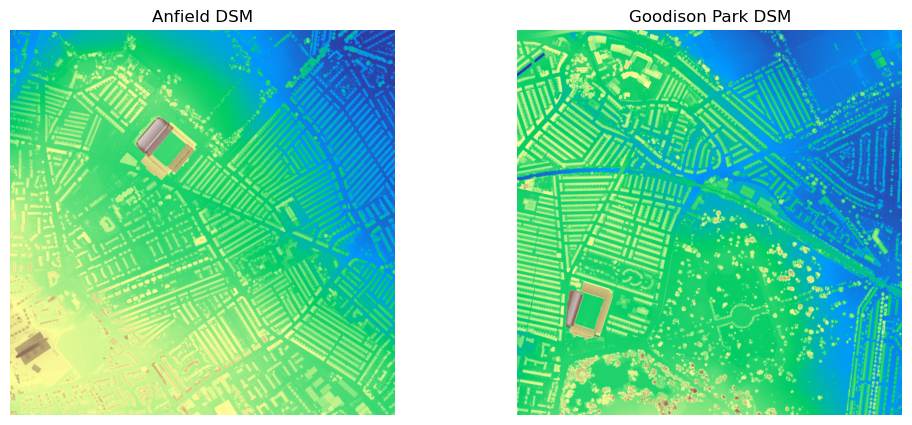

In [4]:
anfield = Path('data/anfield.tif')
dsm_a = rio.open(anfield) 
img_a = dsm_a.read(1)
max_tree_a = sap.MaxTree(img_a) 

goodison = Path('data/goodison_park.tif')
dsm_g = rio.open(goodison) 
img_g = dsm_g.read(1)
max_tree_g = sap.MaxTree(img_g) 

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_a, cmap='terrain')
plt.title('Anfield DSM')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_g, cmap='terrain')
plt.title('Goodison Park DSM')
plt.axis('off')
plt.show()

The following attributes are used to identify stadiums:
- **Area**: Stadiums have large footprints, significantly bigger than regular buildings
- **Height**: Stadium structures (walls, roofs, stands) are elevated above ground level
- **Compactness**: Stadiums have regular shapes, excluding elongated structures like roads or irregular buildings
- **Contour Length**: Used to compute the circularity attribute, which measures shape roundness
- **Dynamics**: Stadiums show strong elevation contrast with their surroundings, making them stand out prominently

Also, to make life easier, I define a function to extract the attributes that are needed to do the stadium extraction. In this function, I also create a new attribute named `circularity` which measures how round a shape is.

`Circularity` is computed using the **Isoperimetric Quotient** formula:

$$\text{Circularity} = \frac{4\pi \times \text{Area}}{\text{Perimeter}^2}$$

The motivation of this new attribute is because stadiums are typically circular or oval-shaped, giving them higher circularity values, compared to regular rectangular buildings. This makes circularity a key attribute for distinguishing stadiums from other structures.

In [5]:
def get_attributes_stadium_detection(max_tree):
    area = max_tree.get_attribute('area')
    height = max_tree.get_attribute('height')
    compactness = max_tree.get_attribute('compactness')
    contour_length = max_tree.get_attribute('contour_length')
    dynamics = max_tree.get_attribute('dynamics')
    
    # Circularity -> perfect circle = 1.0, irregular shapes < 0.5
    circularity = np.where(contour_length > 0, (4 * np.pi * area) / (contour_length ** 2), 0)
    
    return area, height, compactness, contour_length, dynamics, circularity

area_a, height_a, compactness_a, contour_length_a, dynamics_a, circularity_a = get_attributes_stadium_detection(max_tree_a)
area_g, height_g, compactness_g, contour_length_g, dynamics_g, circularity_g = get_attributes_stadium_detection(max_tree_g)

## Image Filtering (Empirically)
At first the idea of using widgets was simply to find the best parameter values to extract the stadium from each DSM. However, after experimenting with them, it became clear that interactive widgets are a very effective way to empirically understand how each attribute influences the selection of nodes in the morphological tree. The widgets allow direct visual feedback, making it easier to observe how changing a single parameter affects the extraction result. The current default values are those that provide the best results (so far) for each stadium, but feel free to explore!



### Field Inclusion Method

One specific challenge when extracting stadiums is that the stadium walls are a high-elevation structures that are easily detected by the filters, while the field inside the stadium has a much lower elevation and is therefore removed during filtering. To address this, a field inclusion step is applied. When enabled, this step fills the stadium interior by thresholding the detected shell, filling the enclosed area, and restoring the original DSM values for both the walls and the field.

#### 1. Anfield Stadium

In [ ]:
# Sliders
area_min_slider = widgets.FloatSlider(
    value=5000,
    min=area_a.min(),
    max=area_a.max(),
    step=1000,
    description='Area min'
)

area_max_slider = widgets.FloatSlider(
    value=100000,
    min=area_a.min(),
    max=area_a.max(),
    step=1000,
    description='Area max'
)

height_min_slider = widgets.FloatSlider(
    value=40,
    min=height_a.min(),
    max=height_a.max(),
    step=1,
    description='Height min'
)

height_max_slider = widgets.FloatSlider(
    value=74,
    min=height_a.min(),
    max=height_a.max(),
    step=1,
    description='Height max'
)

comp_min_slider = widgets.FloatSlider(
    value=0.01,
    min=compactness_a.min(),
    max=compactness_a.max(),
    step=0.05,
    description='Comp min'
)

comp_max_slider = widgets.FloatSlider(
    value=0.11,
    min=compactness_a.min(),
    max=compactness_a.max(),
    step=0.05,
    description='Comp max'
)

circ_min_slider = widgets.FloatSlider(
    value=0.06,
    min=circularity_a.min(),
    max=circularity_a.max(),
    step=0.05,
    description='Circ min'
)

circ_max_slider = widgets.FloatSlider(
    value=0.9,
    min=circularity_a.min(),
    max=circularity_a.max(),
    step=0.05,
    description='Circ max'
)

dyn_percentile_slider = widgets.FloatSlider(
    value=100,
    min=0,
    max=100,
    step=5,
    description='Dynamics %'
)

include_field_checkbox = widgets.Checkbox(
    value=True,
    description='Include field (fill holes)',
    style={'description_width': 'initial'}
)


# Filtering function
def filter_stadium(area_min, area_max, height_min, height_max, 
                   comp_min, comp_max, circ_min, circ_max, 
                   dyn_perc, include_field):
    
    # Select nodes matching criteria
    stadium_nodes = (
        (area_a >= area_min) & (area_a <= area_max) &
        (height_a >= height_min) & (height_a <= height_max) &
        (compactness_a >= comp_min) & (compactness_a <= comp_max) &
        (circularity_a >= circ_min) & (circularity_a <= circ_max) &
        (dynamics_a >= np.percentile(dynamics_a, dyn_perc))
    )
    
    num_nodes = np.sum(stadium_nodes)
    
    # Reconstruct - KEEP matching nodes by DELETING others
    stadium_shell = max_tree_a.reconstruct(deleted_nodes=~stadium_nodes)
    
    # Include field if requested
    if include_field and np.any(stadium_shell > 0):
        threshold = np.percentile(stadium_shell[stadium_shell > 0], 20)
        mask = stadium_shell > threshold
        mask_filled = ndimage.binary_fill_holes(mask)
        filtered = np.where(mask_filled, img_a, 0)
    else:
        filtered = stadium_shell
    
    # Create visualization - BEFORE AND AFTER
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # BEFORE: Original DSM
    axes[0].imshow(img_a, cmap='terrain')
    axes[0].set_title('Original DSM')
    axes[0].axis('off')
    
    # AFTER: Filtered result
    im = axes[1].imshow(filtered, cmap='terrain')
    title = f'Stadium Extracted ({num_nodes} nodes)'
    if include_field:
        title += '\n(with field)'
    else:
        title += '\n(structure only)'
    axes[1].set_title(title)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], label='Elevation')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    if np.any(filtered > 0):
        print(f"✓ Nodes matched: {num_nodes}")
        print(f"✓ Pixels extracted: {np.sum(filtered > 0)}")
        print(f"✓ Elevation range: {filtered[filtered > 0].min():.1f} - {filtered.max():.1f} m")
    else:
        print(f"✗ No nodes matched criteria ({num_nodes} nodes)")
        print("  Try relaxing the parameter ranges")


# UI layout
ui = widgets.VBox([
    widgets.HTML("<h3>Stadium Detection Parameters</h3>"),
    widgets.HTML("<b>Area (footprint size):</b>"),
    area_min_slider, area_max_slider,
    widgets.HTML("<b>Height (elevation):</b>"),
    height_min_slider, height_max_slider,
    widgets.HTML("<b>Compactness (shape regularity):</b>"),
    comp_min_slider, comp_max_slider,
    widgets.HTML("<b>Circularity (roundness):</b>"),
    circ_min_slider, circ_max_slider,
    widgets.HTML("<b>Dynamics (contrast with surroundings):</b>"),
    dyn_percentile_slider,
    widgets.HTML("<b>Field inclusion:</b>"),
    include_field_checkbox
])

out = widgets.interactive_output(
    filter_stadium,
    {
        'area_min': area_min_slider,
        'area_max': area_max_slider,
        'height_min': height_min_slider,
        'height_max': height_max_slider,
        'comp_min': comp_min_slider,
        'comp_max': comp_max_slider,
        'circ_min': circ_min_slider,
        'circ_max': circ_max_slider,
        'dyn_perc': dyn_percentile_slider,
        'include_field': include_field_checkbox
    }
)

display(ui, out)

Output()

### 2. Goodison Park Stadium

In [ ]:
# Sliders
area_min_slider = widgets.FloatSlider(
    value=5000,
    min=area_g.min(),
    max=area_g.max(),
    step=1000,
    description='Area min'
)

area_max_slider = widgets.FloatSlider(
    value=100000,
    min=area_g.min(),
    max=area_g.max(),
    step=1000,
    description='Area max'
)

height_min_slider = widgets.FloatSlider(
    value=25,
    min=height_g.min(),
    max=height_g.max(),
    step=1,
    description='Height min'
)

height_max_slider = widgets.FloatSlider(
    value=49,
    min=height_g.min(),
    max=height_g.max(),
    step=1,
    description='Height max'
)

comp_min_slider = widgets.FloatSlider(
    value=0.01,
    min=compactness_g.min(),
    max=compactness_g.max(),
    step=0.05,
    description='Comp min'
)

comp_max_slider = widgets.FloatSlider(
    value=0.21,
    min=compactness_g.min(),
    max=compactness_g.max(),
    step=0.05,
    description='Comp max'
)

circ_min_slider = widgets.FloatSlider(
    value=0.06,
    min=circularity_g.min(),
    max=circularity_g.max(),
    step=0.05,
    description='Circ min'
)

circ_max_slider = widgets.FloatSlider(
    value=0.9,
    min=circularity_g.min(),
    max=circularity_g.max(),
    step=0.05,
    description='Circ max'
)

dyn_percentile_slider = widgets.FloatSlider(
    value=90,
    min=0,
    max=100,
    step=5,
    description='Dynamics %'
)

include_field_checkbox = widgets.Checkbox(
    value=True,
    description='Include field (fill holes)',
    style={'description_width': 'initial'}
)


# Filtering function
def filter_stadium(area_min, area_max, height_min, height_max, 
                   comp_min, comp_max, circ_min, circ_max, 
                   dyn_perc, include_field):
    
    # Select nodes matching criteria
    stadium_nodes = (
        (area_g >= area_min) & (area_g <= area_max) &
        (height_g >= height_min) & (height_g <= height_max) &
        (compactness_g >= comp_min) & (compactness_g <= comp_max) &
        (circularity_g >= circ_min) & (circularity_g <= circ_max) &
        (dynamics_g >= np.percentile(dynamics_g, dyn_perc))
    )
    
    num_nodes = np.sum(stadium_nodes)
    
    # Reconstruct - KEEP matching nodes by DELETING others
    stadium_shell = max_tree_g.reconstruct(deleted_nodes=~stadium_nodes)
    
    # Include field if requested
    if include_field and np.any(stadium_shell > 0):
        threshold = np.percentile(stadium_shell[stadium_shell > 0], 20)
        mask = stadium_shell > threshold
        mask_filled = ndimage.binary_fill_holes(mask)
        filtered = np.where(mask_filled, img_g, 0)
    else:
        filtered = stadium_shell
    
    # Create visualization - BEFORE AND AFTER
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # BEFORE: Original DSM
    axes[0].imshow(img_g, cmap='terrain')
    axes[0].set_title('Original DSM')
    axes[0].axis('off')
    
    # AFTER: Filtered result
    im = axes[1].imshow(filtered, cmap='terrain')
    title = f'Stadium Extracted ({num_nodes} nodes)'
    if include_field:
        title += '\n(with field)'
    else:
        title += '\n(structure only)'
    axes[1].set_title(title)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], label='Elevation')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    if np.any(filtered > 0):
        print(f"✓ Nodes matched: {num_nodes}")
        print(f"✓ Pixels extracted: {np.sum(filtered > 0)}")
        print(f"✓ Elevation range: {filtered[filtered > 0].min():.1f} - {filtered.max():.1f} m")
    else:
        print(f"✗ No nodes matched criteria ({num_nodes} nodes)")
        print("  Try relaxing the parameter ranges")


# UI layout
ui = widgets.VBox([
    widgets.HTML("<h3>Stadium Detection Parameters</h3>"),
    widgets.HTML("<b>Area (footprint size):</b>"),
    area_min_slider, area_max_slider,
    widgets.HTML("<b>Height (elevation):</b>"),
    height_min_slider, height_max_slider,
    widgets.HTML("<b>Compactness (shape regularity):</b>"),
    comp_min_slider, comp_max_slider,
    widgets.HTML("<b>Circularity (roundness):</b>"),
    circ_min_slider, circ_max_slider,
    widgets.HTML("<b>Dynamics (contrast with surroundings):</b>"),
    dyn_percentile_slider,
    widgets.HTML("<b>Field inclusion:</b>"),
    include_field_checkbox
])

out = widgets.interactive_output(
    filter_stadium,
    {
        'area_min': area_min_slider,
        'area_max': area_max_slider,
        'height_min': height_min_slider,
        'height_max': height_max_slider,
        'comp_min': comp_min_slider,
        'comp_max': comp_max_slider,
        'circ_min': circ_min_slider,
        'circ_max': circ_max_slider,
        'dyn_perc': dyn_percentile_slider,
        'include_field': include_field_checkbox
    }
)

display(ui, out)

Output()

## Discussion

Based on the findings and the discovery process from both stadium images, most attributes effectively helped isolate the stadium structures. However, there are attributes that needs to be highlighted which are `dynamics` and `circularity`.

**Dynamics** : At Anfield Stadium (Example 1), adjusting the dynamics slider return no changes. This is likely because Anfield's stadium structure already has uniformly high elevation contrast compared to its surroundings, so varying the dynamics threshold doesn't significantly alter the selection. However At Goodison Park (Example 2), setting dynamics to 100% returns no results. This occurs because 100% selects only the single highest-contrast node in the entire image, which may be a single pixel rather than the complete stadium structure.

**Circularity** : The circularity attribute shows subtle but important effects. While minimum circularity adjustments produce small visual changes, this attribute is crucial for distinguishing circular/oval stadium shapes from elongated structures like roads, parking lots, or rectangular buildings. It acts as a shape filter that complements the other geometric attributes, ensuring only stadium-like rounded structures are extracted.

Overall, the combination of these attributes provides robust stadium detection, with dynamics and circularity offering fine-tuned control for different stadium configurations and surrounding contexts.